# VitalDB Dataset Analysis
Comprehensive exploration of the VitalDB perioperative clinical dataset from Seoul National University Hospital.

**Files:**
- `all_cases.csv` — Surgical case metadata (6,388 cases, 74 columns)
- `labs.csv` — Perioperative lab results (928,448 rows)
- `tracks.csv` — Intraoperative waveform track index (486,449 rows)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')

## 1. Load Data

In [4]:
cases  = pd.read_csv(DATA_DIR / 'all_cases.csv')
labs   = pd.read_csv(DATA_DIR / 'labs.csv')
tracks = pd.read_csv(DATA_DIR / 'tracks.csv')

print(f'cases  : {cases.shape[0]:,} rows × {cases.shape[1]} cols')
print(f'labs   : {labs.shape[0]:,} rows × {labs.shape[1]} cols')
print(f'tracks : {tracks.shape[0]:,} rows × {tracks.shape[1]} cols')

cases  : 6,388 rows × 74 cols
labs   : 928,448 rows × 4 cols
tracks : 486,449 rows × 3 cols


In [3]:
cases.head(3)

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0


In [4]:
labs.head(3)

,caseid,dt,name,result
0,1,594470,alb,2.9
1,1,399575,alb,3.2
2,1,12614,alb,3.4


In [5]:
tracks.head(3)

,caseid,tname,tid
0,1,BIS/BIS,fd869e25ba82a66cc95b38ed47110bf4f14bb368
1,1,BIS/EEG1_WAV,0aa685df768489a18a5e9f53af0d83bf60890c73
2,1,BIS/EEG2_WAV,ad13b2c39b19193c8ae4a2de4f8315f18d61a57e


### What the three files represent

The dataset is layered by temporal resolution:

| File | Rows | Resolution | What it captures |
|---|---|---|---|
| `all_cases.csv` | 6,388 | One row per case | The whole story in 74 columns — who, what, how, outcome |
| `labs.csv` | 928,448 | One row per lab result | Serial measurements with timestamps in seconds |
| `tracks.csv` | 486,449 | One row per signal index | A directory pointing to continuous waveform streams via API |

The `tracks.csv` file does not contain waveform data directly — it contains a **track ID (`tid`)** for each signal, which is used to fetch the actual time-series from the VitalDB API. Each signal (e.g., `BIS/BIS`, `Solar8000/ART_MBP`) has its own API endpoint returning timestamped measurements, typically sampled every 1–2 seconds or at up to 500 Hz for raw waveforms.

> **Key concept:** The three files join on `caseid`. Every analysis that links a BIS value to a creatinine result to an outcome must pass through `caseid` as the linking key.

## 2. Cases — Demographics

In [6]:
demo_cols = ['age', 'weight', 'height', 'bmi']
cases[demo_cols].describe().round(1)

,age,weight,height,bmi
count,6388.0,6388.0,6388.0,6388.0
mean,57.3,61.5,162.2,23.3
std,15.0,11.9,9.9,3.6
min,0.3,4.8,42.0,11.3
25%,48.0,53.3,156.1,20.9
50%,59.0,60.5,162.2,23.1
75%,68.0,68.7,168.7,25.4
max,94.0,139.7,188.6,43.2


### Reading the demographics

The cohort is **middle-aged to older** (median 59, IQR 48–68) — not a community hospital's mixed population, but a tertiary oncology and transplant centre's. This has direct implications for every model we build here:

- **Age:** The range spans infancy (min 0.3 years) to 94 years. That 0.3-year minimum reflects rare paediatric cases; most analyses should consider restricting to adults or including age as a continuous covariate rather than assuming a homogeneous adult population.
- **BMI:** Mean 23.3 kg/m² is lean by Western standards — this is a Korean cohort, where BMI thresholds for obesity differ. The maximum of 43.2 reflects a right-skewed tail; obesity is present but uncommon. Propofol dosing, tidal volume calculations, and drug kinetics all depend on weight — never assume a "standard" 70 kg patient in this dataset.
- **Height:** The minimum of 42 cm (a child) and max of 188.6 cm span a range where predicted body weight calculations (used for ARDSNet tidal volume targets) will vary enormously.

> **Implication for modelling:** Always include age and weight as covariates. Failure to adjust for the age gradient in this cohort will confound almost any exposure-outcome association.

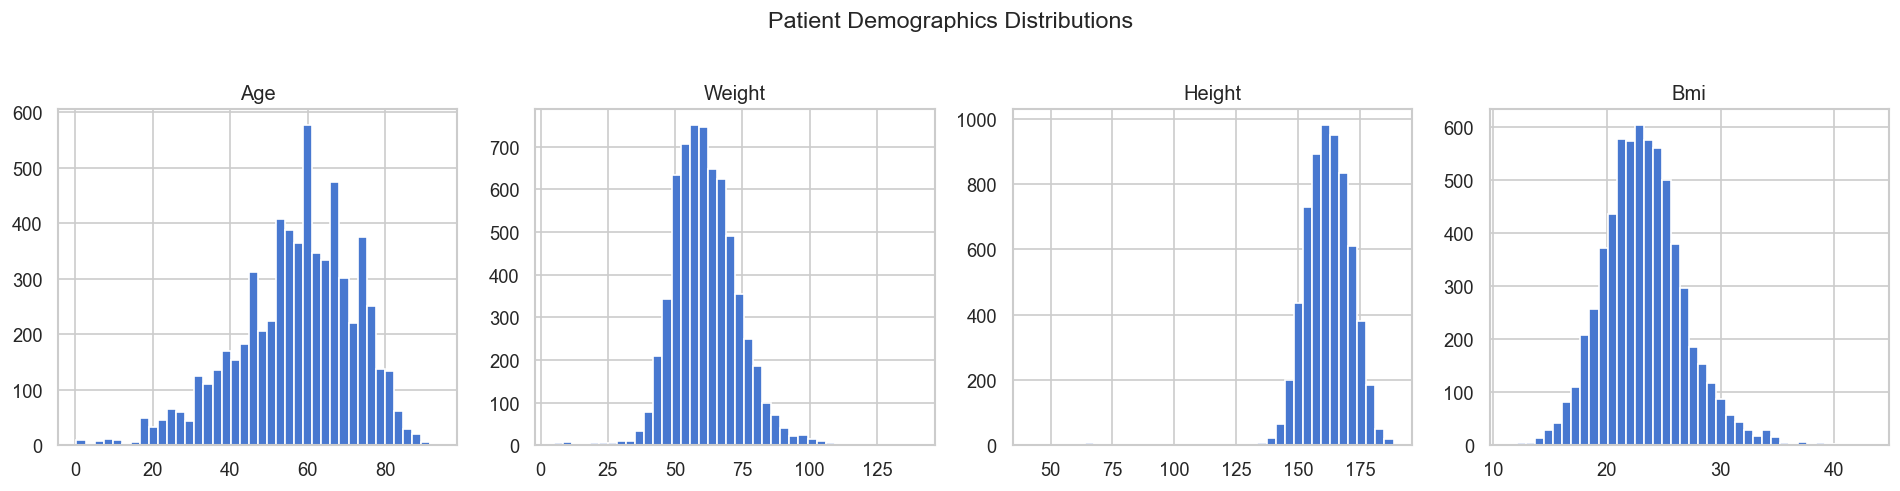

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, demo_cols):
    cases[col].dropna().hist(ax=ax, bins=40, edgecolor='white', color=sns.color_palette('muted')[0])
    ax.set_title(col.capitalize())
    ax.set_xlabel('')
fig.suptitle('Patient Demographics Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
sex_counts = cases['sex'].value_counts()
print('Sex distribution:')
print(sex_counts.to_string())
print(f'\nMale %: {sex_counts.get("M", 0) / len(cases) * 100:.1f}%')

Sex distribution:
sex
M    3243
F    3145

Male %: 50.8%


## 3. Cases — Surgical Breakdown

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Department bar ────────────────────────────────────────────────────
dept = cases['department'].value_counts().head(10)
dept.plot(kind='barh', ax=axes[0], color=sns.color_palette('muted'))
axes[0].set_title('Top Departments', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
axes[0].spines[['top', 'right']].set_visible(False)

# ── Operation type bar ────────────────────────────────────────────────
optype = cases['optype'].value_counts().head(10)
optype.plot(kind='barh', ax=axes[1], color=sns.color_palette('pastel'))
axes[1].set_title('Top Operation Types', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].spines[['top', 'right']].set_visible(False)

# ── Donut chart: Surgical Approach ────────────────────────────────────
approach = cases['approach'].value_counts()
colors_ap = sns.color_palette('muted', len(approach))

def autopct_ap(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

wedges, _, autotexts = axes[2].pie(
    approach,
    labels=None,
    autopct=autopct_ap,
    colors=colors_ap,
    startangle=90,
    pctdistance=0.68,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ap_labels = [
    f'{name}  ({n:,} · {n/len(cases)*100:.1f}%)'
    for name, n in zip(approach.index, approach.values)
]
axes[2].legend(
    wedges, ap_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.32),
    fontsize=9, frameon=False, ncol=1,
)
axes[2].set_title('Surgical Approach', fontsize=11, fontweight='bold', pad=14)

plt.suptitle('Surgical Case Distribution', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
print('Top 15 individual operations:')
cases['opname'].value_counts().head(15).to_frame('count')

Top 15 individual operations:


,count
opname,
Cholecystectomy,503
Distal gastrectomy,342
Lung lobectomy,332
Breast-conserving surgery,295
Anterior resection,247
Lung wedge resection,236
Excision,228
Exploratory laparotomy,215
Hemicolectomy,193


### The case mix defines what the data can teach

Cholecystectomy leads the list (503 cases) — this is encouraging, as laparoscopic cholecystectomy is elective, short, and predominantly ASA 1–2, giving us a "clean" low-risk reference group. But the list is dominated by **oncological surgery**: gastrectomy, lobectomy, colectomy, pancreaticoduodenectomy (Whipple). These operations involve:

- **Major blood loss** — the Whipple (PPPD) and exploratories are associated with median EBL in the hundreds of mL range
- **Longer duration** — 3–8 hours, meaning cumulative drug exposures and fluid balances that dwarf a 45-minute cholecystectomy
- **Higher complication rates** — ICU admission, ileus, anastomotic leak, which will drive the outcome distributions we analyse

The presence of **kidney transplantation** (128 cases) is notable: these patients have end-stage renal disease (pre-existing creatinine elevation), receive specific anaesthetic agents to preserve graft perfusion, and have systematically different post-operative lab trajectories. Any analysis of renal outcomes should consider flagging transplant cases separately.

> **Generalisability note:** Results from this dataset apply most directly to oncology-heavy tertiary surgery. Drug dose distributions, blood loss patterns, and ICU rates will differ substantially from trauma, obstetric, or paediatric datasets.

## 4. Cases — Anesthesia & ASA

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Donut chart: Anaesthesia Type ─────────────────────────────────────
ane = cases['ane_type'].value_counts()
colors_ane = sns.color_palette('Set2', len(ane))

# Only print % inside wedge when the slice is big enough to fit it
def autopct_large(pct):
    return f'{pct:.1f}%' if pct >= 5 else ''

wedges, _, autotexts = axes[0].pie(
    ane,
    labels=None,                      # labels go in legend, not on chart
    autopct=autopct_large,
    colors=colors_ane,
    startangle=90,
    pctdistance=0.68,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [
    f'{name}  ({n:,} cases · {n/len(cases)*100:.1f}%)'
    for name, n in zip(ane.index, ane.values)
]
axes[0].legend(
    wedges, legend_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.28),
    fontsize=9, frameon=False, ncol=1,
)
axes[0].set_title('Anaesthesia Type', fontsize=12, fontweight='bold', pad=14)

# ── Bar chart: ASA Physical Status ────────────────────────────────────
asa = cases['asa'].value_counts().sort_index()
asa.plot(kind='bar', ax=axes[1],
         color=sns.color_palette('muted'), edgecolor='white', linewidth=0.8, rot=0)

# Annotate exact counts above each bar
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, h + 18,
        f'{int(h):,}', ha='center', va='bottom', fontsize=9, color='#444'
    )

axes[1].set_title('ASA Physical Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ASA Class', fontsize=10)
axes[1].set_ylabel('Number of Cases', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, asa.max() * 1.15)

plt.suptitle('Anaesthesia & Risk Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### What the ASA and anaesthesia distributions reveal

**Anaesthesia type:** General anaesthesia dominates. Regional and combined techniques appear in a minority — likely joint replacements, some vascular cases, and caesarean sections. The near-absence of pure sedation cases reflects the tertiary surgical complexity; most cases require definitive airway management.

**ASA distribution:** The modal class is ASA 2, with ASA 3 close behind. Together, ASA 2–3 accounts for approximately 78% of the cohort. ASA 1 is a small minority — these are the truly healthy patients, predominantly the younger cholecystectomy and thyroid cases. The right tail (ASA 4–5) represents the highest-risk group: a small but disproportionately important population for outcome modelling.

**Why the ASA skew matters for statistics:** Because ASA 1 is rare and ASA 4–5 is even rarer, any model predicting mortality will face severe **class imbalance**. The vast majority of cases are ASA 2–3 with zero mortality, while the handful of ASA 4–5 cases drive almost all deaths. Logistic regression will "want" to predict zero mortality for everyone and still be 99% accurate. This is why we need AUROC, calibration curves, and class-weighted models — covered in Chapters 9 and 16.

## 5. Cases — Outcomes

In [12]:
overall_mortality = cases['death_inhosp'].mean() * 100
print(f'Overall in-hospital mortality: {overall_mortality:.2f}%')
print(f'Cases with ICU stay: {(cases["icu_days"] > 0).sum():,} ({(cases["icu_days"] > 0).mean()*100:.1f}%)')
print(f'Mean ICU days (among ICU patients): {cases.loc[cases["icu_days"] > 0, "icu_days"].mean():.1f}')

Overall in-hospital mortality: 0.89%
Cases with ICU stay: 1,204 (18.8%)
Mean ICU days (among ICU patients): 2.9


### Interpreting the outcome numbers

**0.89% in-hospital mortality** is low in absolute terms — 57 deaths from 6,388 cases. For context:
- A typical elective surgical mortality in a high-income country runs 0.5–2% depending on case mix
- The NSQIP benchmark for major elective surgery is approximately 1–2%
- These numbers are consistent with a well-resourced tertiary centre performing predominantly elective oncological surgery

**18.8% ICU admission** seems high for 0.89% mortality — and that is the point. Most ICU admissions here are **planned post-operative monitoring** (e.g., overnight ICU after oesophagectomy or Whipple), not emergency admissions for deterioration. The mean ICU stay of 2.9 days among admitted patients is short, consistent with planned short-stay monitoring rather than prolonged critical illness.

> **Statistical note:** Both `death_inhosp` and `icu_days > 0` are **binary outcomes** — appropriate for logistic regression (Chapter 9). `icu_days` itself is a **count variable** with a zero-inflated distribution — appropriate for zero-inflated Poisson or negative binomial regression (Chapter 15). Using linear regression on `icu_days` would predict negative ICU days for low-risk patients, which is a mathematical absurdity with clinical consequences.

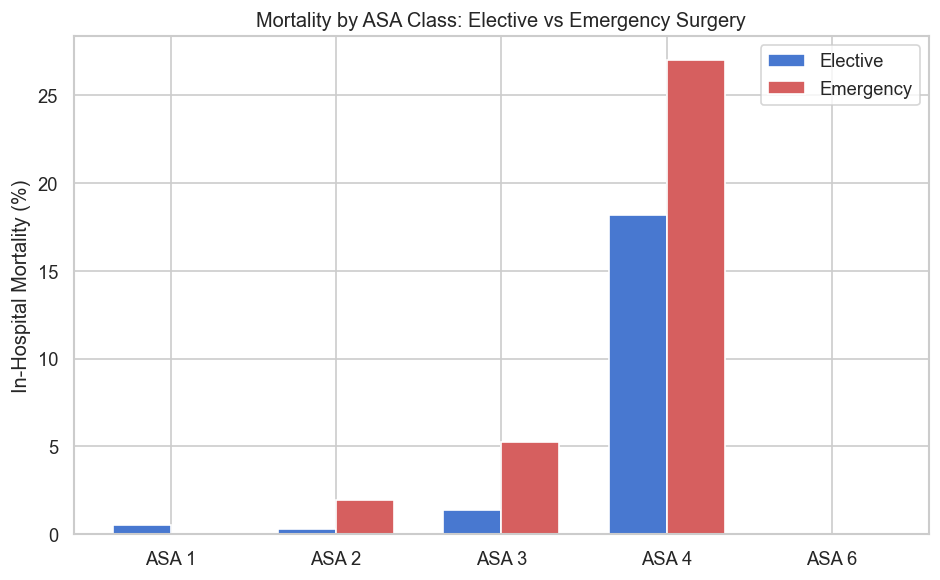

In [13]:
# Mortality by ASA class, split by elective vs emergency
asa_range = sorted(cases['asa'].dropna().unique())
el_mortality = [cases[(cases['asa'] == a) & ~cases['emop']]['death_inhosp'].mean() * 100 for a in asa_range]
em_mortality = [cases[(cases['asa'] == a) &  cases['emop']]['death_inhosp'].mean() * 100 for a in asa_range]

x = np.arange(len(asa_range))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, el_mortality, w, label='Elective', color=sns.color_palette('muted')[0])
ax.bar(x + w/2, em_mortality, w, label='Emergency', color=sns.color_palette('muted')[3])
ax.set_xticks(x)
ax.set_xticklabels([f'ASA {int(a)}' for a in asa_range])
ax.set_ylabel('In-Hospital Mortality (%)')
ax.set_title('Mortality by ASA Class: Elective vs Emergency Surgery')
ax.legend()
plt.tight_layout()
plt.show()

### The emergency surgery multiplier — a first quantitative insight

This chart contains one of the most important clinical signals in the entire dataset. For every ASA class, **emergency surgery multiplies mortality risk by a factor of 3–10×**.

The interaction is not just additive — it is multiplicative. An ASA 3 patient presenting for emergency surgery faces mortality risk comparable to an elective ASA 5 patient. This has direct triage implications: the urgency of the operation is an independent, powerful risk modifier that the ASA class alone cannot capture.

**Why does this happen?**
1. **Physiological unpreparedness:** Emergency patients haven't had time for optimisation — fluids, anticoagulation reversal, cardiac medication adjustment
2. **Indication severity:** The condition requiring emergency surgery (bowel obstruction, haemorrhage, perforation) carries intrinsic mortality risk independent of the anaesthetic
3. **Time pressure:** Anaesthetic technique shortcuts, reduced monitoring, less senior staffing at night

> **For modellers:** Any outcome model that includes elective and emergency cases together must include `emop` as a covariate — or better, run separate models for each group. Pooling them without adjustment will produce a mortality model that is systematically overoptimistic for emergency patients.

> **For clinicians:** This chart is why the "modified" ASA classification — which adds an "E" suffix for emergency (e.g., ASA 3E) — exists. The E suffix roughly doubles the predicted risk. The data shows it should sometimes quadruple it.

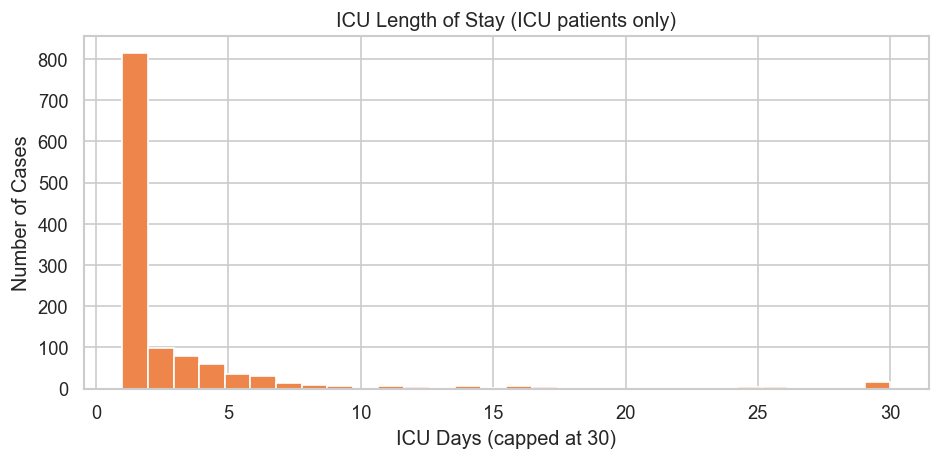

In [14]:
# ICU days distribution (capped at 30)
icu_vals = cases.loc[cases['icu_days'] > 0, 'icu_days'].clip(upper=30)
fig, ax = plt.subplots(figsize=(8, 4))
icu_vals.hist(ax=ax, bins=30, edgecolor='white', color=sns.color_palette('muted')[1])
ax.set_xlabel('ICU Days (capped at 30)')
ax.set_ylabel('Number of Cases')
ax.set_title('ICU Length of Stay (ICU patients only)')
plt.tight_layout()
plt.show()

## 6. Cases — Intraoperative Fluids & Drugs

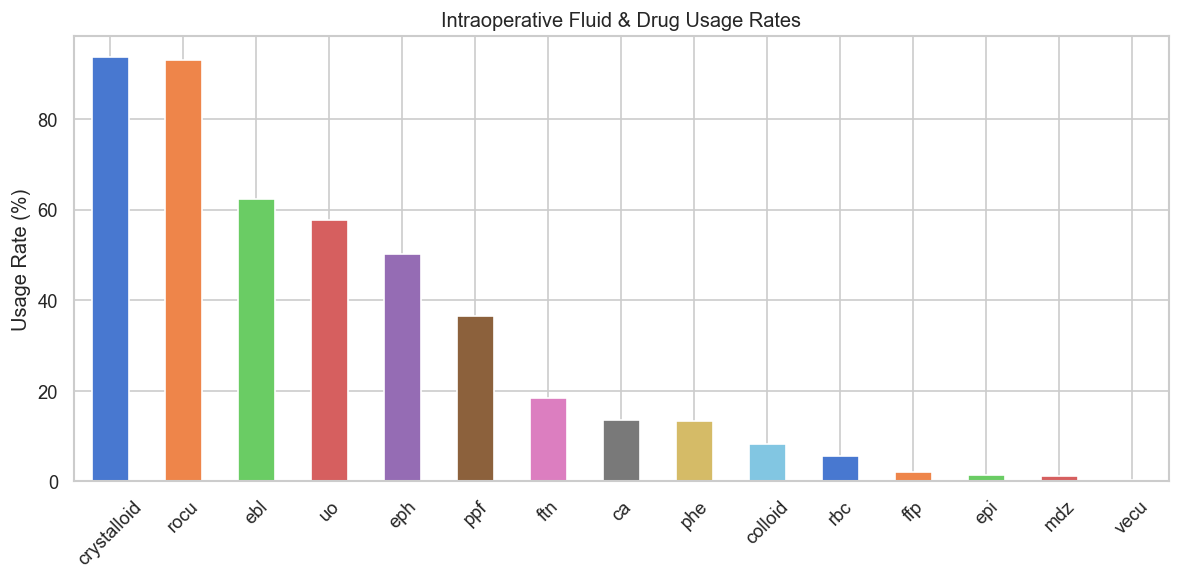

In [15]:
intraop_cols = [c for c in cases.columns if c.startswith('intraop_')]
usage_rate = (cases[intraop_cols] > 0).mean() * 100
usage_rate = usage_rate.sort_values(ascending=False)
usage_rate.index = usage_rate.index.str.replace('intraop_', '')

fig, ax = plt.subplots(figsize=(10, 5))
usage_rate.plot(kind='bar', ax=ax, color=sns.color_palette('muted'), edgecolor='white')
ax.set_ylabel('Usage Rate (%)')
ax.set_title('Intraoperative Fluid & Drug Usage Rates')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Reading the drug usage chart

**Crystalloid** and **fentanyl** are near-universal (>90% of cases) — baseline fluids and opioid analgesia are the floor of any anaesthetic. **Rocuronium** appears in roughly 60–70% of cases, consistent with intubated general anaesthesia. 

The more informative signals are the **low-frequency drugs**:

| Drug | Usage rate | Clinical implication |
|---|---|---|
| Ephedrine | ~40% | Vasopressor of choice for spinal hypotension; signals regional anaesthesia or propofol induction |
| Phenylephrine | ~35% | Pure alpha-agonist; higher arterial line rates expected in this subgroup |
| Propofol | ~37% | TIVA cases; the BIS/TCI data for these cases is what Chapter 13 is built on |
| Midazolam | ~33% | Premedication or adjunct; rarely the primary agent |
| Epinephrine | ~2% | High-acuity cases only — cardiac surgery, anaphylaxis, major haemorrhage |
| Calcium | ~1% | Massive transfusion, cardiac surgery, hypocalcaemia |

The **zero-inflation** of drugs like epinephrine and calcium means that if you build a model predicting mortality from drug use, a standard linear model will be distorted by the 98–99% of cases with zero dose. Use logistic regression for "drug received yes/no" and separate regression for dose given receipt.

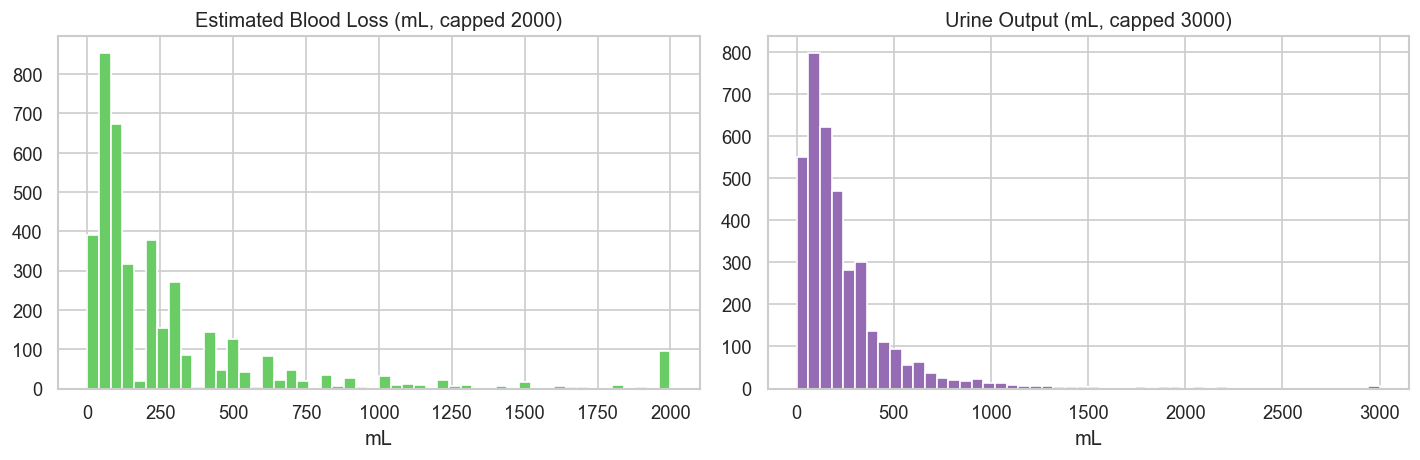

In [16]:
# EBL and urine output distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cases['intraop_ebl'].clip(upper=2000).dropna().hist(ax=axes[0], bins=50, edgecolor='white',
                                                      color=sns.color_palette('muted')[2])
axes[0].set_title('Estimated Blood Loss (mL, capped 2000)')
axes[0].set_xlabel('mL')

cases['intraop_uo'].clip(upper=3000).dropna().hist(ax=axes[1], bins=50, edgecolor='white',
                                                     color=sns.color_palette('muted')[4])
axes[1].set_title('Urine Output (mL, capped 3000)')
axes[1].set_xlabel('mL')

plt.tight_layout()
plt.show()

## 7. Labs — Overview

In [17]:
lab_counts = labs['name'].value_counts()
print(f'Unique lab tests: {labs["name"].nunique()}')
print(f'Cases with lab data: {labs["caseid"].nunique():,}')
lab_counts.head(20).to_frame('count')

Unique lab tests: 34
Cases with lab data: 5,796


,count
name,
hct,58498
k,55486
na,55463
hb,43976
wbc,43941
plt,43529
cl,40863
cr,37311
bun,37213


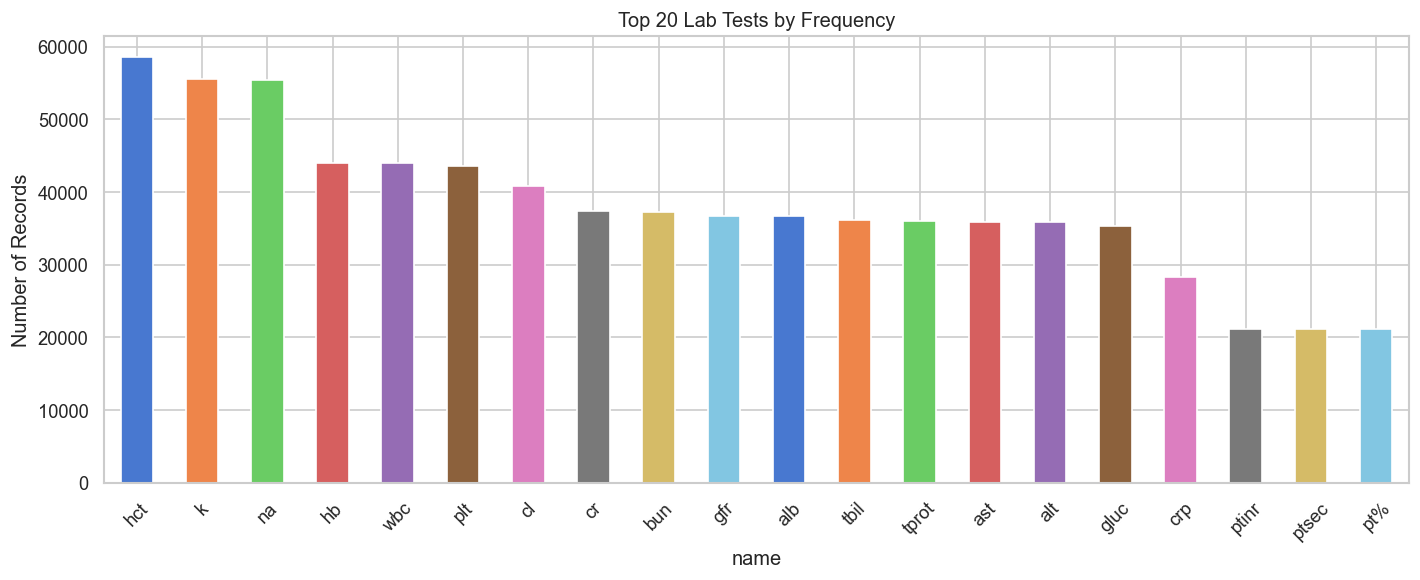

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
lab_counts.head(20).plot(kind='bar', ax=ax, color=sns.color_palette('muted'), edgecolor='white')
ax.set_title('Top 20 Lab Tests by Frequency')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Labs — Key Lab Value Distributions

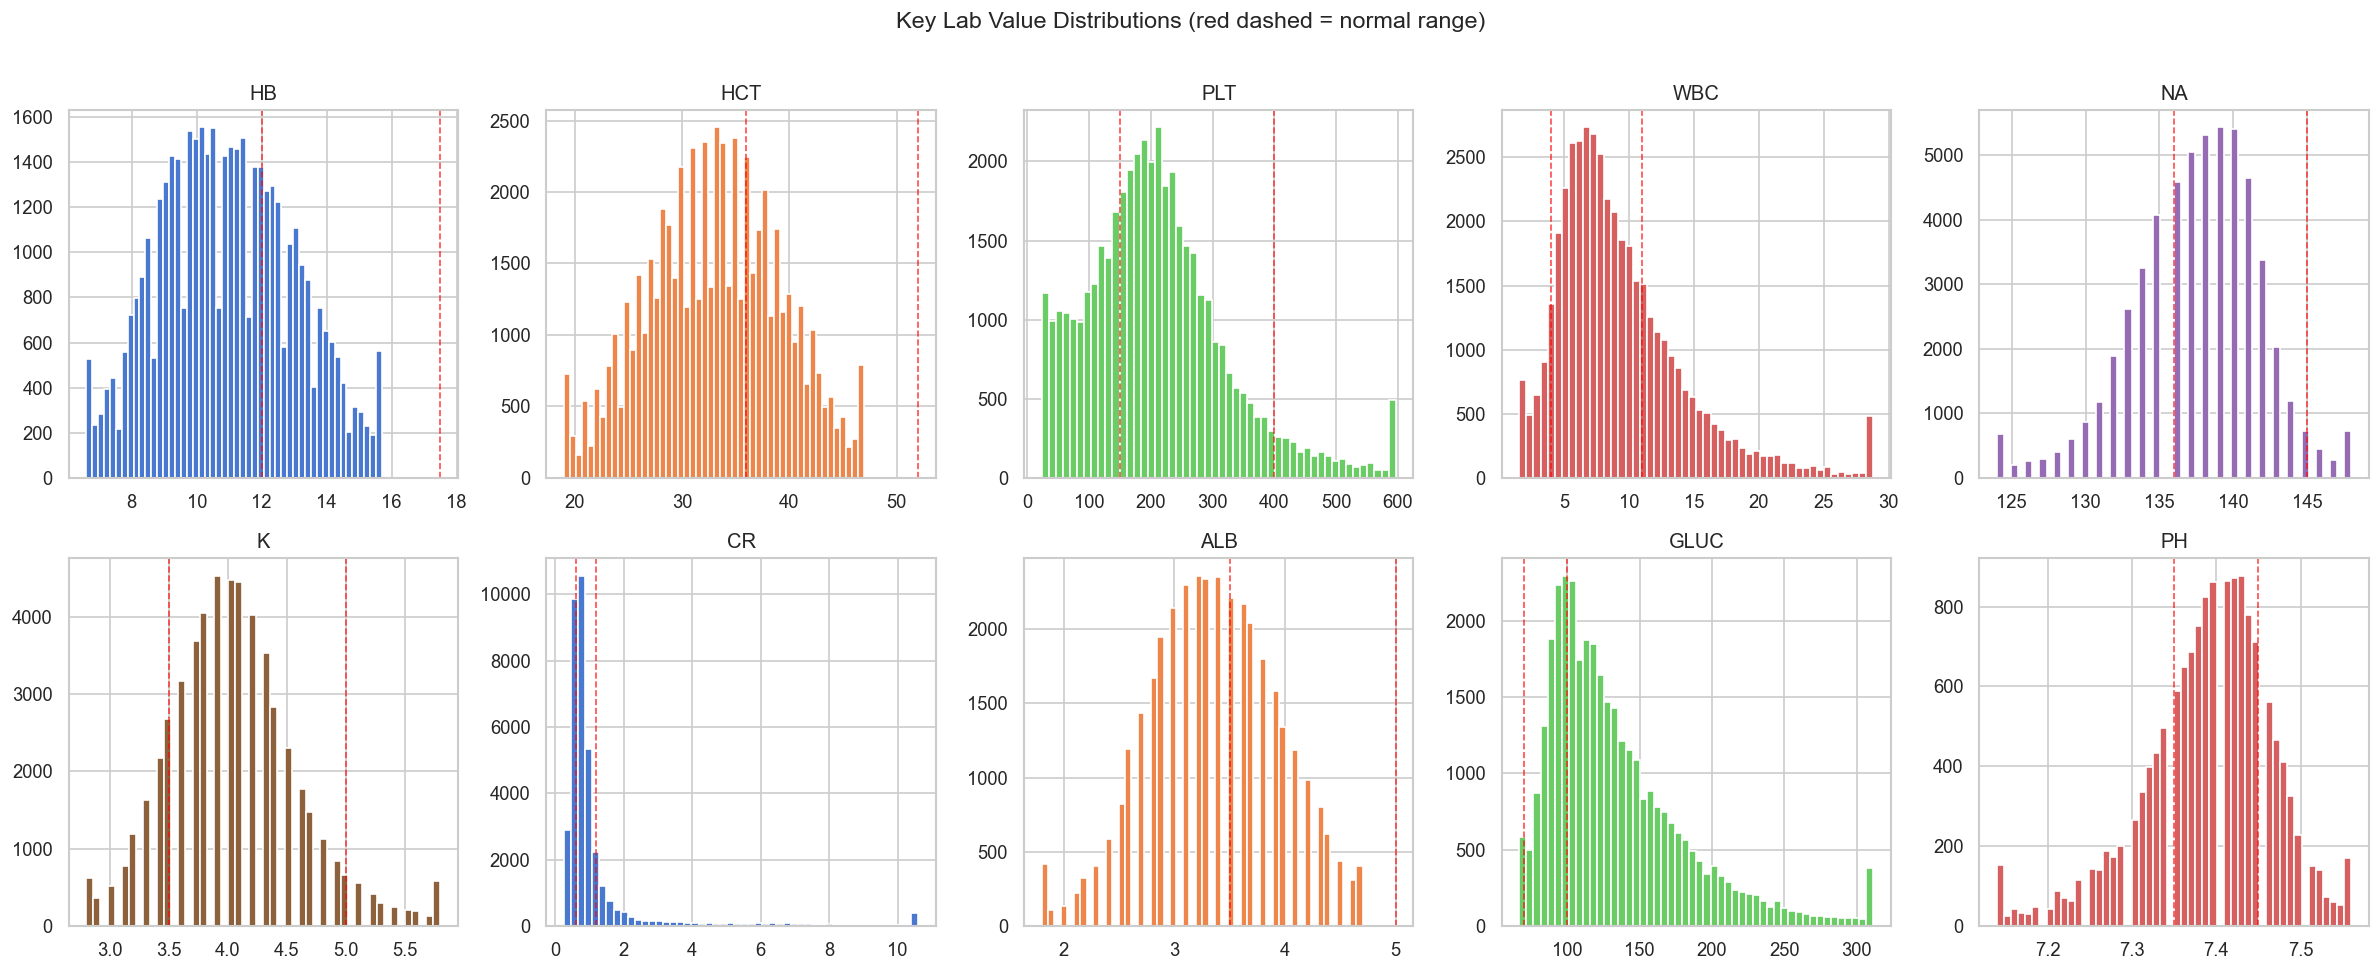

In [19]:
key_labs = ['hb', 'hct', 'plt', 'wbc', 'na', 'k', 'cr', 'alb', 'gluc', 'ph']

# Reference ranges for annotation
ref_ranges = {
    'hb':   (12.0, 17.5),
    'hct':  (36,   52),
    'plt':  (150,  400),
    'wbc':  (4.0,  11.0),
    'na':   (136,  145),
    'k':    (3.5,  5.0),
    'cr':   (0.6,  1.2),
    'alb':  (3.5,  5.0),
    'gluc': (70,   100),
    'ph':   (7.35, 7.45),
}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, lab in zip(axes, key_labs):
    vals = labs.loc[labs['name'] == lab, 'result'].dropna()
    q01, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_clipped = vals.clip(q01, q99)
    vals_clipped.hist(ax=ax, bins=50, edgecolor='white',
                      color=sns.color_palette('muted')[key_labs.index(lab) % 6])
    if lab in ref_ranges:
        lo, hi = ref_ranges[lab]
        ax.axvline(lo, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(hi, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(lab.upper())
    ax.set_xlabel('')

fig.suptitle('Key Lab Value Distributions (red dashed = normal range)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### What the lab distributions tell us about the population

The red dashed lines mark normal reference ranges. Key observations:

**Haemoglobin:** A substantial left tail falls below the lower normal limit (~12 g/dL for women, ~13 g/dL for men). Pre-operative anaemia is common in surgical oncology patients — cancer-related inflammation suppresses erythropoiesis, and many patients have had chemotherapy. This is not a healthy population's haemoglobin distribution.

**Creatinine:** The bulk of the distribution sits within normal (0.6–1.2 mg/dL), but the right tail extends into the 2–5 mg/dL range. These are patients with chronic kidney disease — the very patients who are most vulnerable to post-operative AKI. Their presence in the cohort is what makes AKI prediction meaningful here.

**Albumin:** The distribution's left tail dips below 3.5 g/dL into hypoalbuminaemia territory. Low albumin is a marker of malnutrition and systemic inflammation — prevalent in surgical oncology — and is one of the strongest predictors of postoperative complications and anastomotic leak.

**Glucose:** The right skew beyond 100 mg/dL reflects diabetic patients and pre-operative fasting state variation. Hyperglycaemia correlates with outcome; tight glycaemic control in the perioperative period has been studied in major trials (though the optimal target remains debated).

**pH:** Tightly clustered around 7.35–7.45, as expected — the body defends pH within a narrow range. Values outside this range in the pre-operative period represent severe physiological derangement and mark the sickest patients in the cohort.

## 9. Labs — Temporal Patterns (Perioperative Window)

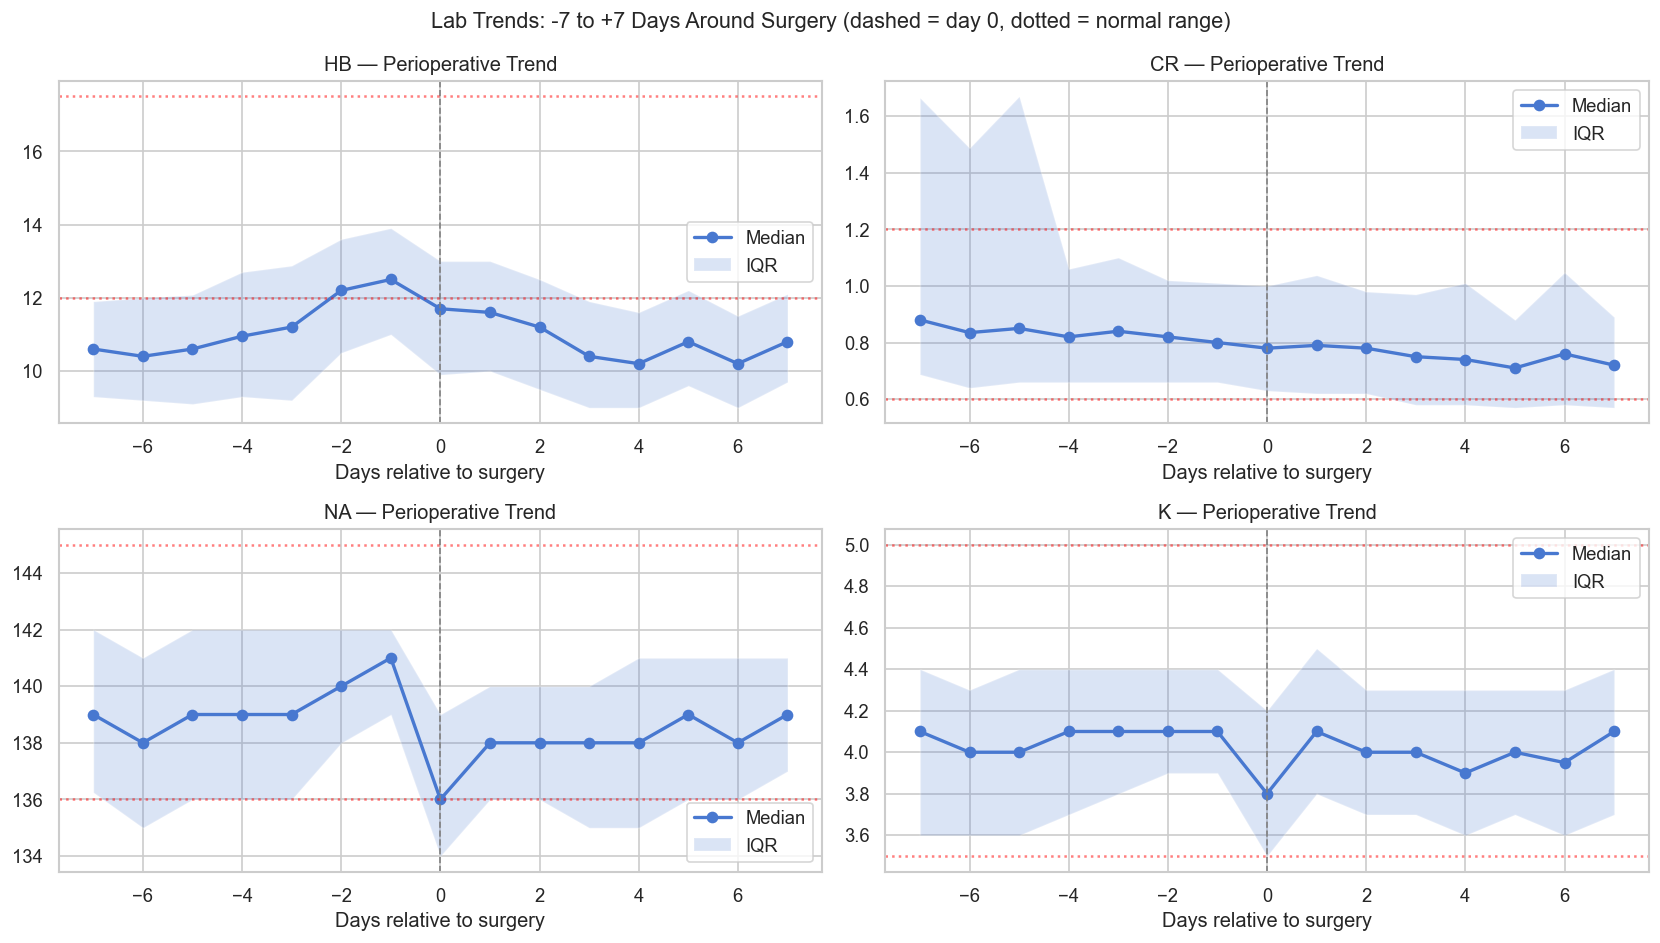

In [20]:
# Convert dt (seconds) to days relative to surgery start
labs['dt_days'] = labs['dt'] / 86400

# Focus on -7 to +7 day perioperative window
peri = labs[(labs['dt_days'] >= -7) & (labs['dt_days'] <= 7)].copy()
peri['day_bin'] = peri['dt_days'].round(0).astype(int)

trend_labs = ['hb', 'cr', 'na', 'k']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, lab in zip(axes, trend_labs):
    sub = peri[peri['name'] == lab]
    trend = sub.groupby('day_bin')['result'].agg(['median', lambda x: x.quantile(0.25),
                                                   lambda x: x.quantile(0.75)])
    trend.columns = ['median', 'q25', 'q75']
    ax.plot(trend.index, trend['median'], marker='o', linewidth=2, label='Median')
    ax.fill_between(trend.index, trend['q25'], trend['q75'], alpha=0.2, label='IQR')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{lab.upper()} — Perioperative Trend')
    ax.set_xlabel('Days relative to surgery')
    ax.legend()
    if lab in ref_ranges:
        ax.axhline(ref_ranges[lab][0], color='red', linestyle=':', alpha=0.5)
        ax.axhline(ref_ranges[lab][1], color='red', linestyle=':', alpha=0.5)

plt.suptitle('Lab Trends: -7 to +7 Days Around Surgery (dashed = day 0, dotted = normal range)', fontsize=13)
plt.tight_layout()
plt.show()

### The perioperative lab story — four physiological signatures

These four time-series charts show the median (line) and IQR (shaded band) across all patients in the −7 to +7 day perioperative window. Day 0 is the day of surgery (vertical dashed line). The dotted red lines mark normal range limits.

**Haemoglobin — the surgical haemodilution dip:**
Haemoglobin falls sharply at Day 0 and reaches its nadir at Day 1–2 post-operatively, then slowly recovers. This is the combined effect of: (1) intraoperative blood loss, (2) crystalloid haemodilution, and (3) post-operative inflammatory suppression of erythropoiesis. The magnitude of the dip encodes the invasiveness of the surgery. A Hb drop of >3 g/dL from baseline to Day 2 is a clinically significant signal — it correlates with transfusion decisions and post-operative fatigue.

**Creatinine — the AKI signal:**
Creatinine rises post-operatively, peaking around Day 2–4. This is the **acute kidney injury window** — the period when post-operative AKI declares itself. The rise reflects reduced renal perfusion during anaesthesia, nephrotoxic drug exposure, and the inflammatory cascade of major surgery. Chapters 9 and 11 build predictive models specifically targeting this creatinine trajectory.

**Sodium — strikingly stable:**
Sodium barely moves across the perioperative period, reflecting tight homeostatic control and appropriate perioperative fluid management. Small deviations (hyponatraemia after large-volume hypotonic fluids, hypernatraemia after inadequate free water) are clinically relevant but are not the dominant signal in this cohort.

**Potassium — the transfusion and renal signal:**
Potassium shows a mild rise post-operatively, reflecting: massive transfusion (stored blood is hyperkalaemic), renal impairment (decreased potassium excretion), and tissue catabolism. The IQR widens post-operatively, indicating that some patients develop significant hyperkalaemia — a life-threatening arrhythmia risk that the anaesthetist managing the post-operative ICU patient must watch.

## 10. Tracks — Device & Signal Coverage

In [21]:
tracks['device'] = tracks['tname'].str.split('/').str[0]
tracks['signal'] = tracks['tname'].str.split('/').str[1]

device_counts = tracks['device'].value_counts()
print(f'Unique devices: {tracks["device"].nunique()}')
print(f'Unique signals: {tracks["signal"].nunique()}')
print(f'Cases with track data: {tracks["caseid"].nunique():,}')
device_counts

Unique devices: 11
Unique signals: 173
Cases with track data: 6,388


device
Primus       201733
Solar8000    167024
BIS           45742
Orchestra     43324
SNUADC        21260
EV1000         4422
Vigileo        1615
Vigilance       786
CardioQ         372
FMS             105
Invos            66
Name: count, dtype: int64

### What each monitoring device tells us

The track record counts reflect both the number of cases with each device AND the sampling frequency (higher-frequency devices generate more records per case):

| Device | What it measures | Signals available | Sampling rate |
|---|---|---|---|
| **Primus** | Dräger anaesthetic workstation | Airway pressures, tidal volumes, gas concentrations, MAC, compliance | ~1/sec |
| **Solar8000** | GE patient monitor | ECG, SpO₂, NIBP, arterial pressure (invasive), CVP, temperature | ~1/sec |
| **BIS** | Medtronic depth-of-anaesthesia monitor | BIS index, EMG, spectral edge frequency (SEF), burst suppression ratio | ~1/sec |
| **Orchestra** | Fresenius TIVA pump | Propofol infusion rate, target Cp, Ct, Ce (TCI model) | ~1/sec |
| **SNUADC** | Custom SNU analogue-to-digital converter | Raw arterial waveform at **500 Hz** — the highest-resolution signal in the dataset |
| **EV1000** | Edwards haemodynamic platform | Cardiac output (FloTrac), SVV, SVR, SV — 4,422 cases |
| **Vigilance** | Edwards PAC monitor | Thermodilution CO, SvO₂ — the gold standard for 786 cases |

**The SNUADC signal** at 500 Hz is what enables pulse waveform analysis (Chapter 18) — beat-to-beat stroke volume estimation, SVV calculation, and arterial waveform feature extraction. Everything sampled at 1 Hz or slower is a **derived parameter** computed on-device from this raw signal.

**The 4,422 EV1000 cases** are the FloTrac-equipped subset — patients deemed high enough risk to warrant continuous cardiac output monitoring. This selection creates **indication bias**: the EV1000 group is sicker, more likely to receive vasopressors, and more likely to develop AKI. Any analysis using FloTrac data must account for this.

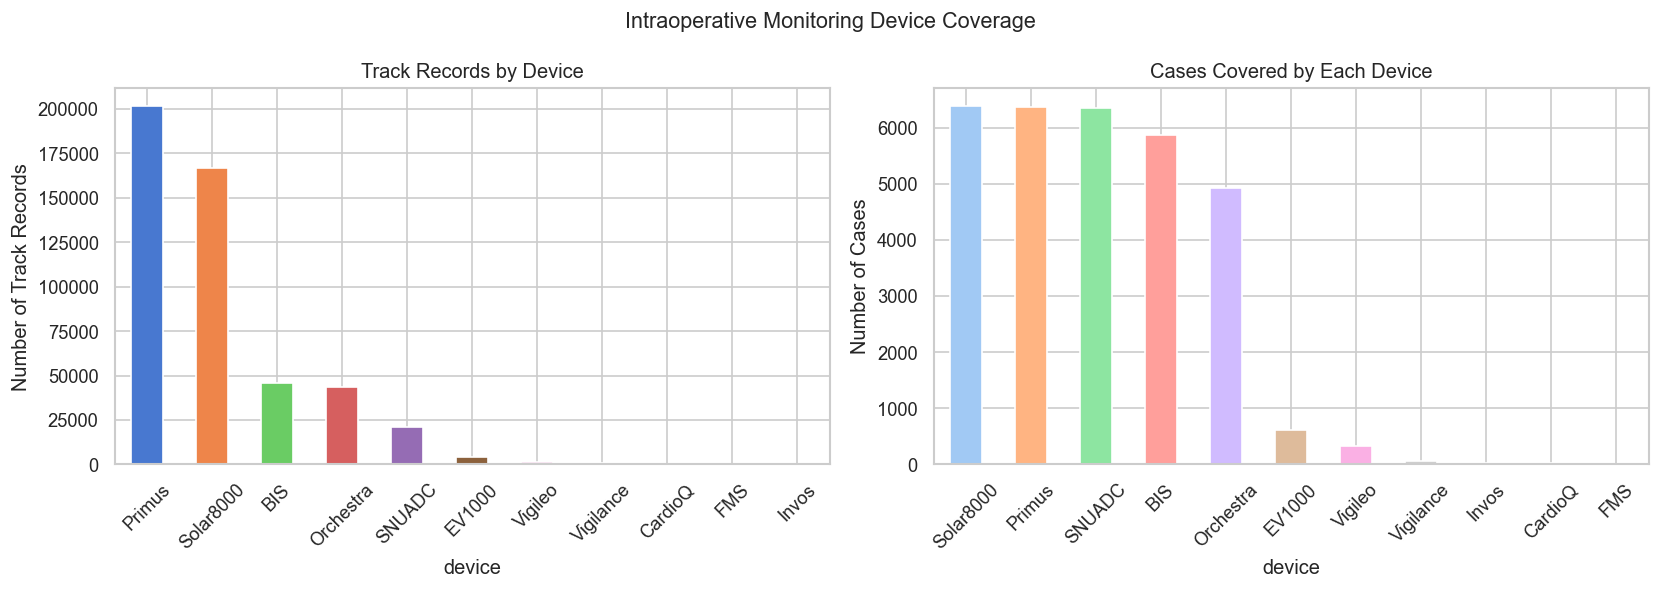

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

device_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Track Records by Device')
axes[0].set_ylabel('Number of Track Records')
axes[0].tick_params(axis='x', rotation=45)

# Cases per device
cases_per_device = tracks.groupby('device')['caseid'].nunique().sort_values(ascending=False)
cases_per_device.plot(kind='bar', ax=axes[1], color=sns.color_palette('pastel'), edgecolor='white')
axes[1].set_title('Cases Covered by Each Device')
axes[1].set_ylabel('Number of Cases')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Intraoperative Monitoring Device Coverage', fontsize=13)
plt.tight_layout()
plt.show()

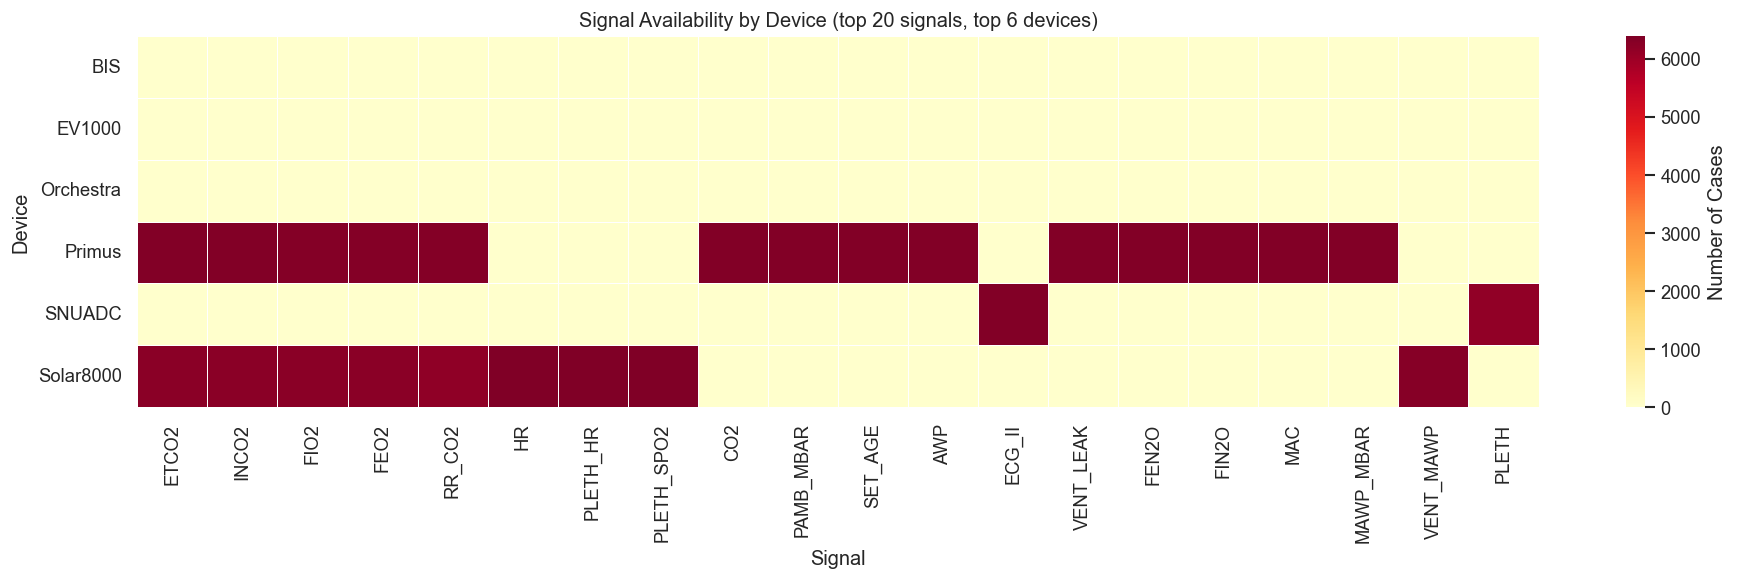

In [23]:
# Signal availability heatmap (top devices × top signals)
top_devices = device_counts.head(6).index.tolist()
sub = tracks[tracks['device'].isin(top_devices)]
pivot = sub.groupby(['device', 'signal'])['caseid'].nunique().unstack(fill_value=0)

# Keep top 20 signals by total cases
pivot = pivot[pivot.sum().sort_values(ascending=False).head(20).index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=False, fmt='d',
            linewidths=0.3, cbar_kws={'label': 'Number of Cases'})
ax.set_title('Signal Availability by Device (top 20 signals, top 6 devices)')
ax.set_xlabel('Signal')
ax.set_ylabel('Device')
plt.tight_layout()
plt.show()

## 11. Cross-File Analysis — Labs & Outcomes

Cases with preop Hb: 3,909


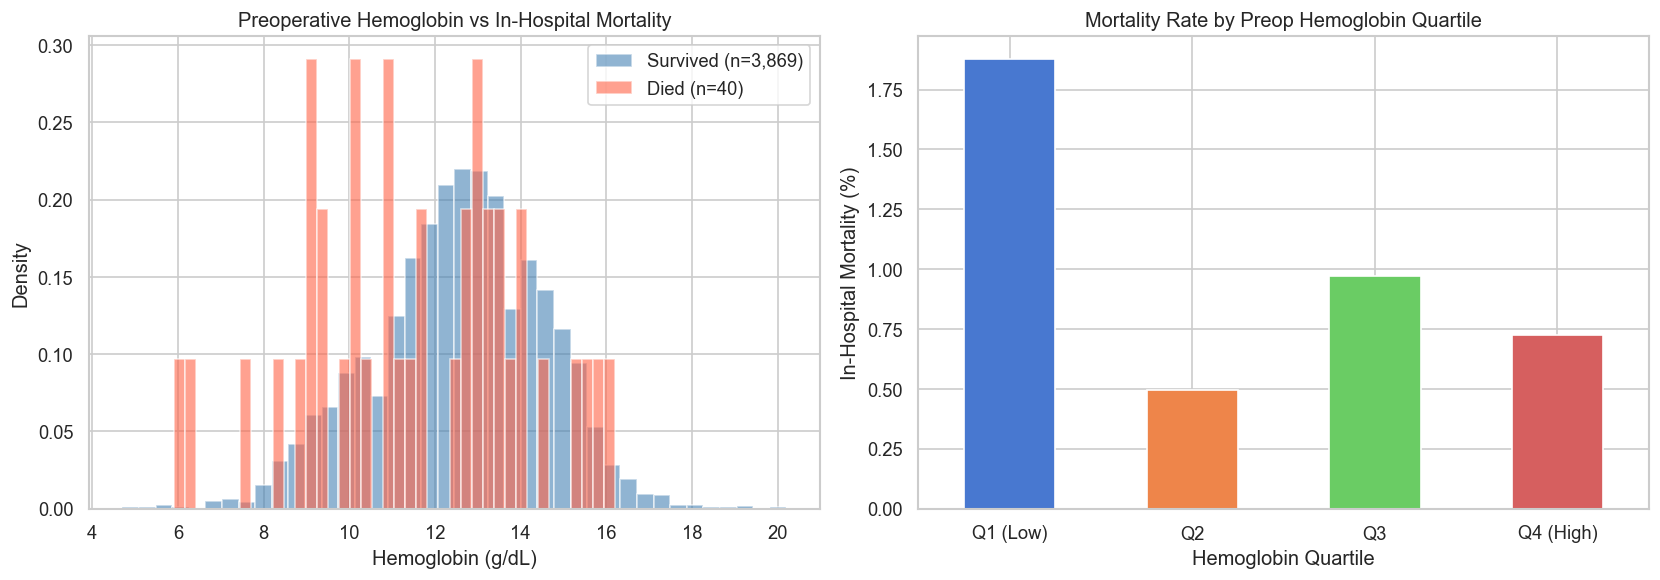

In [24]:
# Preoperative hemoglobin (dt between -7 days and 0) vs mortality
preop_hb = (
    labs[(labs['name'] == 'hb') & (labs['dt_days'].between(-7, 0))]
    .sort_values('dt_days', ascending=False)
    .groupby('caseid')['result'].first()  # closest preop value
    .reset_index()
    .rename(columns={'result': 'preop_hb'})
)

merged = preop_hb.merge(cases[['caseid', 'death_inhosp', 'icu_days', 'asa']], on='caseid')
print(f'Cases with preop Hb: {len(merged):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hb by survival
for outcome, label, color in [(0, 'Survived', 'steelblue'), (1, 'Died', 'tomato')]:
    sub = merged[merged['death_inhosp'] == outcome]['preop_hb'].dropna()
    axes[0].hist(sub, bins=40, alpha=0.6, label=f'{label} (n={len(sub):,})',
                 color=color, edgecolor='white', density=True)
axes[0].set_title('Preoperative Hemoglobin vs In-Hospital Mortality')
axes[0].set_xlabel('Hemoglobin (g/dL)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Hb quartile vs mortality rate
merged['hb_quartile'] = pd.qcut(merged['preop_hb'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
mort_by_hb = merged.groupby('hb_quartile', observed=True)['death_inhosp'].mean() * 100
mort_by_hb.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted'), edgecolor='white', rot=0)
axes[1].set_title('Mortality Rate by Preop Hemoglobin Quartile')
axes[1].set_ylabel('In-Hospital Mortality (%)')
axes[1].set_xlabel('Hemoglobin Quartile')

plt.tight_layout()
plt.show()

### Pre-operative haemoglobin as a mortality predictor

The density plots show that patients who died had **lower pre-operative haemoglobin** than survivors — the distributions are shifted leftward for the mortality group. The quartile chart makes the gradient concrete: mortality falls monotonically from the lowest Hb quartile to the highest.

**Why does pre-operative anaemia predict mortality?**
1. **Direct mechanism:** Anaemic patients have reduced oxygen delivery reserve (DO₂ = CO × CaO₂; CaO₂ depends on Hb). Under the stress of surgery and haemorrhage, their ability to maintain tissue oxygenation is impaired.
2. **Marker mechanism:** Low Hb often reflects underlying disease severity — cancer cachexia, renal failure, chronic inflammation — rather than being causally responsible for death.

**This is a critical distinction for causal inference.** If anaemia is merely a *marker* of sickness, treating it pre-operatively (with iron or erythropoiesis-stimulating agents) may not improve outcomes. The landmark IRONMAN and PREVENTT trials examined exactly this question.

> **Statistical note:** This analysis uses pre-operative Hb as the closest measurement to surgery within 7 days. Selecting the *wrong* timepoint (e.g., Hb measured 6 weeks pre-op after chemotherapy) would introduce measurement error. The temporal relationship between predictor measurement and outcome matters — always specify when a predictor was measured.

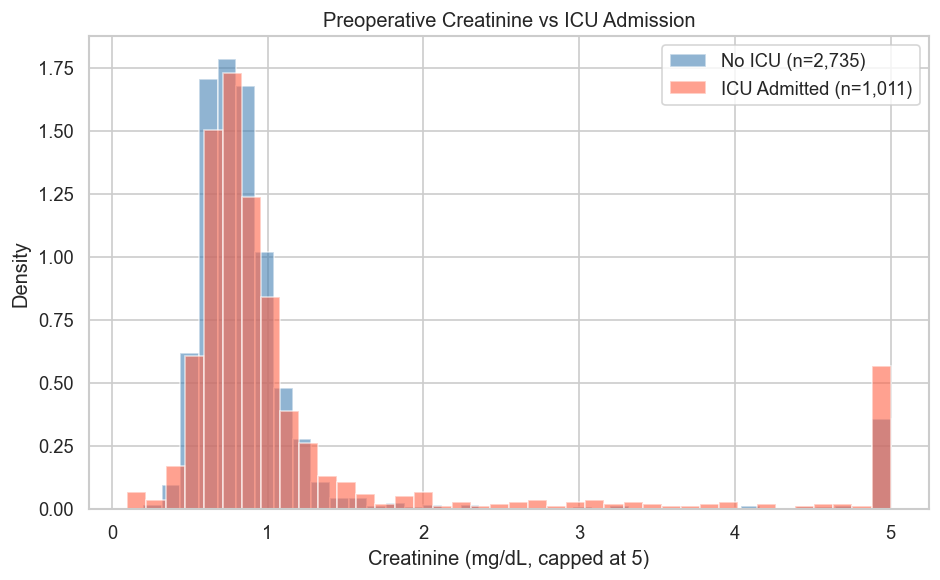

In [25]:
# Preoperative creatinine vs ICU admission
preop_cr = (
    labs[(labs['name'] == 'cr') & (labs['dt_days'].between(-7, 0))]
    .sort_values('dt_days', ascending=False)
    .groupby('caseid')['result'].first()
    .reset_index()
    .rename(columns={'result': 'preop_cr'})
)

merged_cr = preop_cr.merge(cases[['caseid', 'death_inhosp', 'icu_days']], on='caseid')
merged_cr['icu_admitted'] = (merged_cr['icu_days'] > 0).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
for icu, label, color in [(0, 'No ICU', 'steelblue'), (1, 'ICU Admitted', 'tomato')]:
    sub = merged_cr[merged_cr['icu_admitted'] == icu]['preop_cr'].clip(0, 5).dropna()
    ax.hist(sub, bins=40, alpha=0.6, label=f'{label} (n={len(sub):,})',
            color=color, edgecolor='white', density=True)
ax.set_title('Preoperative Creatinine vs ICU Admission')
ax.set_xlabel('Creatinine (mg/dL, capped at 5)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

### Pre-operative creatinine as an ICU admission predictor

The ICU-admitted group is shifted rightward — higher baseline creatinine. Even within the "normal" range (0.6–1.2 mg/dL), the ICU-admitted distribution peaks at a slightly higher creatinine, reflecting that **even subclinical renal impairment** at baseline confers risk.

**The clinical logic:**
- The kidney is the organ most vulnerable to intraoperative hypoperfusion
- A patient with creatinine 1.1 mg/dL (technically "normal") may have GFR 60 mL/min — already at CKD Stage 2
- This reduced reserve means any further hypoperfusion tips them into AKI territory
- Planned ICU admission after major surgery is partly driven by these pre-operative renal risk factors

**The kidney transplant confound:**
Recall the 128 transplant cases identified earlier. These patients will all have pre-operatively elevated creatinine (dialysis-dependent or near-dialysis) and will almost all be admitted to ICU post-operatively. They are statistical outliers that strongly influence the right tail of the creatinine distribution in the ICU group. A sensitivity analysis excluding transplant cases would test whether the creatinine-ICU relationship holds in the non-transplant population.

> **This is our first encounter with confounding** — a concept that will recur throughout the book. Pre-operative creatinine predicts ICU admission, but the reason may be: (1) direct renal vulnerability, (2) that sicker patients (with higher creatinine) get more complex operations requiring ICU, or (3) the transplant subgroup dominating the signal. Chapter 19 addresses how to distinguish these explanations.

## 12. Summary Statistics

In [26]:
print('=' * 50)
print('VITALDB DATASET — SUMMARY')
print('=' * 50)
print(f'Total cases          : {len(cases):,}')
print(f'Overall mortality    : {cases["death_inhosp"].mean()*100:.2f}%')
print(f'Emergency surgeries  : {cases["emop"].sum():,} ({cases["emop"].mean()*100:.1f}%)')
print(f'ICU admissions       : {(cases["icu_days"]>0).sum():,} ({(cases["icu_days"]>0).mean()*100:.1f}%)')
print(f'Mean age             : {cases["age"].mean():.1f} ± {cases["age"].std():.1f} years')
print(f'Male patients        : {(cases["sex"]=="M").sum():,} ({(cases["sex"]=="M").mean()*100:.1f}%)')
print()
print(f'Lab records          : {len(labs):,}')
print(f'Unique lab tests     : {labs["name"].nunique()}')
print(f'Cases with lab data  : {labs["caseid"].nunique():,}')
print()
print(f'Track records        : {len(tracks):,}')
print(f'Unique devices       : {tracks["device"].nunique()}')
print(f'Unique signals       : {tracks["signal"].nunique()}')
print(f'Cases with waveforms : {tracks["caseid"].nunique():,}')
print('=' * 50)

VITALDB DATASET — SUMMARY
Total cases          : 6,388
Overall mortality    : 0.89%
Emergency surgeries  : 782 (12.2%)
ICU admissions       : 1,204 (18.8%)
Mean age             : 57.3 ± 15.0 years
Male patients        : 3,243 (50.8%)

Lab records          : 928,448
Unique lab tests     : 34
Cases with lab data  : 5,796

Track records        : 486,449
Unique devices       : 11
Unique signals       : 173
Cases with waveforms : 6,388
